In [1]:
import sys
import os

# Get the absolute path to the parent directory (CSCI5527-FINAL)
parent_dir = os.path.abspath("..")

# Add the parent directory to the system path if it's not already there
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [2]:
import torch
import torch.optim as optim
import torch.nn as nn
import segmentation_models_pytorch as smp
from fastai.losses import DiceLoss, CrossEntropyLossFlat

import io
import pandas as pd
from contextlib import redirect_stdout, redirect_stderr
import tqdm

from matrices import *
from preprocessing import *
from utils import *

In [3]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.backends.cudnn.is_available())
n_gpu = torch.cuda.device_count()
print(f"Total GPUs available: {n_gpu}")
for i in range(n_gpu):
    print(f"Device {i}: {torch.cuda.get_device_name(i)}")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
print(f"Using {device} device")
generator = torch.Generator(device=device)

2.11.0+cu126
True
True
Total GPUs available: 1
Device 0: NVIDIA GeForce RTX 4070 SUPER
Using cuda:0 device


In [4]:
def baseline_model_pipeline(base_dir, dict_files):
    # Locate project root and TACK data folders dynamically relative to the script location
    dataset_folder = os.path.join(base_dir, "TACK_Tunnel_Data")

    csv_source_dir = os.path.join(dataset_folder, "2_model_input")
    raw_mask_dir = os.path.join(dataset_folder, "3_mask")

    # Initialize pipeline pointing to the TTD dataset structure
    pipeline = TunnelDataPipeline(
        base_dir=dataset_folder,
        original_mask_dir=raw_mask_dir
    )

    # Define standard training splits for the multi-domain tunnel study
    train_files = dict_files["train_files"]
    val_files = dict_files["val_files"]
    test_files = dict_files["test_files"]

    # Step 1: Load metadata
    print("Loading CSV metadata...")
    df_train_val, df_test = pipeline.load_csv_data(
        csv_source_dir=csv_source_dir,
        train_files=train_files,
        val_files=val_files,
        test_files=test_files
    )

    # Step 2: Sanitize and separate training/validation masks
    print("Sanitizing training and validation masks...")
    df_train_val_ready = pipeline.sanitize_masks(df_train_val, class_pixel_value=40)

    # Step 3: Sanitize test masks
    print("Sanitizing test masks...")
    df_test_ready = pipeline.sanitize_masks(df_test, class_pixel_value=40)

    # Step 4: Compute dataset-specific normalization values
    custom_stats = pipeline.calculate_training_stats(df_train_val_ready)

    # Step 5: Finalize DataLoaders for the training loop
    print("Generating Dataloaders...")
    train_dl, val_dl, test_dl = pipeline.get_dataloaders(
        train_val_df=df_train_val_ready,
        test_df=df_test_ready,
        bs=16,
        img_size=512,
        custom_stats=custom_stats
    )

    # Final summary of training readiness
    print(f"\nPipeline Ready:")
    print(f" - Training batches: {len(train_dl)}")
    print(f" - Validation batches: {len(val_dl)}")
    print(f" - Testing batches: {len(test_dl)}")

    return train_dl, val_dl, test_dl, custom_stats

In [5]:
config = {
    "train_files": ["TA_train.csv", "TB_train.csv", "TC_train.csv"],
    "val_files": ["TA_val.csv", "TB_val.csv", "TC_val.csv"],
    "test_files": ["TA_test.csv", "TB_test.csv", "TC_test.csv"]
}
train_dl, val_dl, test_dl, custom_stats = baseline_model_pipeline(parent_dir, config)

Loading CSV metadata...
Sanitizing training and validation masks...


Sanitizing Masks: 100%|██████████| 1360/1360 [00:00<00:00, 6833.28it/s]


Sanitizing test masks...


Sanitizing Masks: 100%|██████████| 156/156 [00:00<00:00, 6500.02it/s]


Calculating custom dataset statistics...


Computing Stats: 100%|██████████| 1058/1058 [00:15<00:00, 68.37it/s]


Generating Dataloaders...

Pipeline Ready:
 - Training batches: 66
 - Validation batches: 19
 - Testing batches: 10


In [6]:
from dff import *

model = smp.Unet("resnet34", encoder_weights=None, classes=2)
model_name = "Unet-resnet34-no_weight_Multi-Domain"
model.load_state_dict(torch.load(os.path.join("models", f"{model_name}.pth")))
model.to(device)
model.eval()
target_layer = model.encoder.layer4[-1]

Calculating NMF errors for k in [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]...


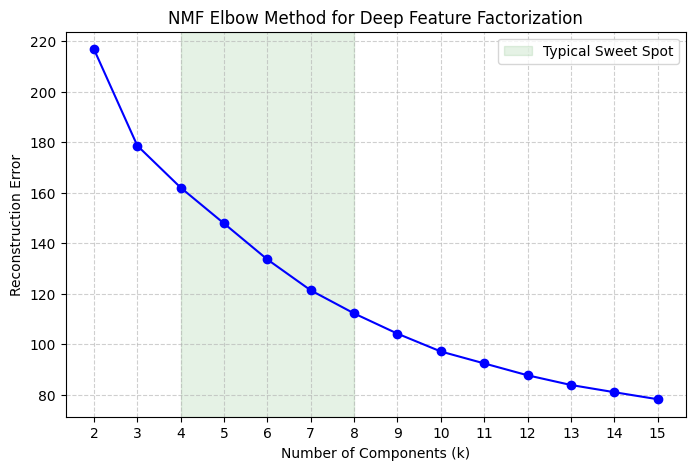

In [7]:
plot_nmf_elbow(model, test_dl, target_layer, device, k_range=range(2, 16))

In [8]:
print(f"Running DFF analysis for {model_name}...")
find_situations_and_run_dff(
    model=model,
    dataloader=test_dl,
    target_layer=target_layer,
    device=device,
    save_dir=os.path.join("figures", "dff_analysis"),
    custom_stats=custom_stats,
    n_components=6
)

Running DFF analysis for Unet-resnet34-no_weight_Multi-Domain...
Scanning dataloader for edge cases (TP, FP, FN, TN)...


c:\Users\markf\.conda\envs\tunnel\Lib\site-packages\torch\utils\_device.py:116: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


Saved TP visual to figures\dff_analysis\DFF_Analysis_TP.png
Saved FP visual to figures\dff_analysis\DFF_Analysis_FP.png
Saved FN visual to figures\dff_analysis\DFF_Analysis_FN.png


c:\Users\markf\.conda\envs\tunnel\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


Saved TN visual to figures\dff_analysis\DFF_Analysis_TN.png
